<a href="https://colab.research.google.com/github/bozhenkaaa/technOfMachineLearning3/blob/main/Dz3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, accuracy_score, confusion_matrix
from scipy.optimize import linear_sum_assignment
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
# Визначення пристрою
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Завантаження переднатренованої моделі ResNet-18
weights = torchvision.models.ResNet18_Weights.DEFAULT
model = torchvision.models.resnet18(weights=weights)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 150MB/s]


In [3]:
# Створення фіче-екстрактора
feature_extractor = nn.Sequential(
    model.conv1,
    model.bn1,
    model.relu,
    model.maxpool,
    model.layer1,
    model.layer2,
    model.layer3,
    model.layer4,
    model.avgpool
)
feature_extractor.to(device)
feature_extractor.eval()

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Con

In [4]:
# Перетворення для CIFAR-10
transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [5]:
# Завантаження CIFAR-10
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

100%|██████████| 170M/170M [00:02<00:00, 83.3MB/s]


In [6]:
# Функція для витягування ознак зображення
def extract_features(dataloader):
    features = []
    labels = []
    with torch.no_grad():
        for inputs, target in tqdm(dataloader):
            inputs = inputs.to(device)
            output = feature_extractor(inputs)
            output = output.view(output.size(0), -1)  # Перетворення векторів ознак у плоский вигляд
            features.append(output.cpu().numpy())
            labels.append(target.numpy())
    return np.concatenate(features, axis=0), np.concatenate(labels, axis=0)

In [7]:
X_train, y_train = extract_features(trainloader)
X_test, y_test = extract_features(testloader)

100%|██████████| 157/157 [16:37<00:00,  6.36s/it]


In [27]:
# Алгоритм кластеризації KMeans
n_clusters = 10
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(X_train)

y_pred = kmeans.predict(X_test)

In [9]:
silhouette = silhouette_score(X_test, y_pred)
print(f"Silhouette score: {silhouette}")

Silhouette score: 0.04321126267313957


In [10]:
# Обчислення точності класифікації
def match_clusters_to_classes(y_true, y_pred, n_clusters):
    confusion = np.zeros((n_clusters, 10))
    for i in range(len(y_true)):
        confusion[y_pred[i], y_true[i]] += 1

    row_ind, col_ind = linear_sum_assignment(-confusion)
    return col_ind

# Визначення відповідності між кластерами та класами
cluster_to_class = match_clusters_to_classes(y_train, kmeans.predict(X_train), n_clusters)

In [18]:
# Точність класифікації
accuracy = accuracy_score(y_test, cluster_to_class[y_pred])
print(f"Accuracy: {accuracy * 100:.2f}%")

conf_matrix = confusion_matrix(y_test, cluster_to_class[y_pred])
print("Confusion Matrix:")
print(conf_matrix)

Accuracy: 59.10%
Confusion Matrix:
[[550  17   6  42   4   0  20   6 316  39]
 [  2 849   0  19   1   0   1   0  24 104]
 [ 64   1 423 147  29  10 204 101  21   0]
 [  2   6   9 474 369  42  74  15   5   4]
 [  1   0  16  80  74   1 371 430  26   1]
 [  1   1   3 278 145 487  19  63   2   1]
 [ 10   1  49  57 242   2 626   8   5   0]
 [  1   1   8 185  57  11  18 684  23  12]
 [ 17  47   0  26   2   0   4   0 877  27]
 [  7  75   0  10   2   0   1   3  36 866]]


In [29]:
# Передбачення кластерів на тренувальних даних
y_train_pred = kmeans.predict(X_train)

train_accuracy = accuracy_score(y_train, cluster_to_class[y_train_pred])
print(f"Train Accuracy: {train_accuracy * 100:.2f}%")

train_conf_matrix = confusion_matrix(y_train, cluster_to_class[y_train_pred])
print("Train Confusion Matrix:")
print(train_conf_matrix)

Train Accuracy: 59.10%
Train Confusion Matrix:
[[2696  114   37  217   16    0   99   44 1629  148]
 [   5 4300    1   71    5    0   13    2   79  524]
 [ 273    5 2069  754  170   43  961  627   96    2]
 [  16   24   36 2428 1839  198  334   69   31   25]
 [  29    1   96  392  354    7 1676 2304  136    5]
 [   3    6   25 1317  880 2340  109  306    7    7]
 [  44   13  300  309 1027   10 3256   15   23    3]
 [  20    2   24  912  275   45   83 3448  133   58]
 [  66  197    1  176   10    2   32    4 4380  132]
 [  23  406    0   72    7    0   11    7  194 4280]]


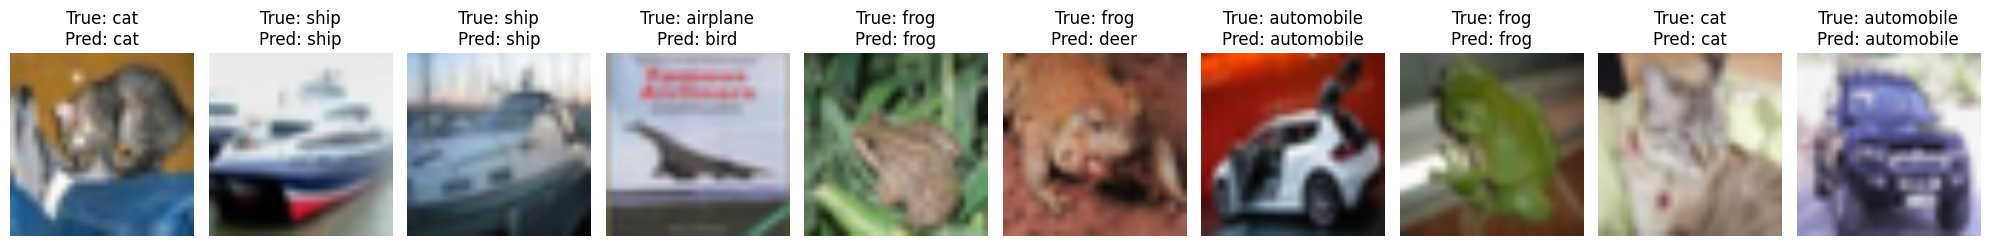

In [26]:
sample_images = []
sample_labels = []
for i in range(10):
    img, label = testset[i]
    sample_images.append(img)
    sample_labels.append(label)

inputs = torch.stack(sample_images).to(device)

with torch.no_grad():
    outputs = feature_extractor(inputs)
    features = outputs.view(outputs.size(0), -1).cpu().numpy()

sample_preds = kmeans.predict(features)

def denormalize(img_tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = img_tensor.numpy().transpose((1, 2, 0))
    img = std * img + mean
    return np.clip(img, 0, 1)

sample_images_np = [denormalize(img) for img in sample_images]

# Візуалізуємо
visualize_clusters(
    images=sample_images_np,
    y_true=sample_labels,
    y_pred=sample_preds,
    cluster_to_class=dict(enumerate(cluster_to_class)),
    n_images=10
)